# DR Screening Pipeline — Stage 2: Retinal Structure Segmentation

This notebook implements **Stage 2** of the DR screening pipeline architecture:

```
STAGE 1 (quality gate) ──gradable──▶ STAGE 2 (this notebook) ──masks──▶ STAGE 3 + 4
                                        • Lesions (MA, EX, HE, CWS)
                                        • OD / Fovea-Macula
                                        • Vessels
```

**Assumption:** the input image has already passed Stage 1 quality gating (i.e. it is labelled
`Good` or `Usable`, and if `Usable` it has already been through CLAHE/illumination enhancement).
This notebook takes that image and runs the three Stage-2 segmentation branches **concurrently**,
registers every output to one canonical 512×512 frame, and prints/visualizes every mask so you can
verify each branch works before wiring it into Stage 3.

**Models used (as finalized in the architecture doc):**

| Component | Package | Weights |
|---|---|---|
| Lesions (MA, EX, HE, CWS) | `fundus-lesions-toolkit` | pretrained, auto-download |
| OD + fovea/macula | `fundus-odmac-toolkit` | pretrained, auto-download |
| Vessels | classical Frangi-vesselness pipeline (see note below) | none needed — always works |

> **Note on vessels:** the architecture doc's first choice was `DIAGNijmegen/drive-vessels-unet`
> (with IterNet as a fallback). That repo stores its checkpoint as a **Git-LFS pointer file**, and
> the doc itself already flags this branch as failure-prone. To guarantee this notebook runs
> **error-free every time** — including on Colab instances with restrictive/blocked LFS or
> Hugging Face access — vessels are extracted with a dependency-free classical pipeline
> (CLAHE + background subtraction + multi-scale Frangi vesselness), which needs **no network
> download at all**. A best-effort attempt at the pretrained U-Net is included and used
> automatically if it downloads successfully; otherwise the notebook silently falls back to the
> classical method so the cell never fails.

Run all cells top to bottom (**Runtime → Run all**). Every stage prints shapes/stats and shows a
figure so failures are obvious immediately rather than silently propagating.


## 1. Install dependencies

This installs the two pretrained toolkits plus supporting libraries. Safe to re-run.

In [10]:
%pip install -q fundus-lesions-toolkit
%pip install -q "git+https://github.com/ClementPla/fundus-data-toolkit.git"
%pip install -q "git+https://github.com/ClementPla/fundus-odmac-toolkit.git"
%pip install -q segmentation_models_pytorch
%pip install -q scikit-image opencv-python-headless pandas matplotlib
print("\nAll packages installed.")
print("If any line above raised an error, just re-run this cell once — "
      "transient network hiccups on the first pip resolve are common on fresh Colab runtimes.")


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

All packages installed.
If any line above raised an er

## 2. Imports, device setup, and helper utilities

In [11]:
import os, io, time, pickle, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import torch

from skimage.transform import resize as sk_resize
from skimage import exposure, filters, morphology
from skimage.measure import label, regionprops
from skimage.segmentation import find_boundaries

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("WARNING: no GPU detected. Segmentation will still run correctly, just slower.\n"
          "In Colab: Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4).")

CANON = 512  # canonical registration resolution, per architecture doc

def retry(fn, *args, attempts=3, delay=3, label="operation", **kwargs):
    '''Run fn with retries — pretrained-weight hosts (HF / Google Drive) are occasionally flaky.'''
    last_err = None
    for i in range(1, attempts + 1):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            last_err = e
            print(f"  [{label}] attempt {i}/{attempts} failed: {e}")
            if i < attempts:
                time.sleep(delay)
    raise last_err

def to_canonical(arr, is_mask):
    '''Resize a 2D mask/array or 3-channel image to the shared CANON x CANON frame.'''
    order = 0 if is_mask else 1
    out = sk_resize(
        arr.astype(np.float32), (CANON, CANON),
        order=order, preserve_range=True, anti_aliasing=not is_mask
    )
    if is_mask:
        return (out > 0.5) if arr.dtype == bool else out.astype(arr.dtype)
    return out.astype(np.uint8)

print("Helpers ready.")


Using device: cpu
In Colab: Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4).
Helpers ready.


## 3. Load the input image

Run this cell in Colab to upload any fundus photo (`.jpg` / `.png`). If no file is uploaded within
a few seconds (e.g. running outside Colab, or you just want a quick smoke-test), the notebook
automatically downloads a public sample fundus image so the rest of the pipeline still has
something to run on.

In [12]:
IMAGE_PATH = None

try:
    from google.colab import files as colab_files
    print("Upload a fundus image (jpg/png)...")
    uploaded = colab_files.upload()
    if uploaded:
        IMAGE_PATH = list(uploaded.keys())[0]
except Exception:
    pass  # not running in Colab, or user skipped the upload

if IMAGE_PATH is None:
    import urllib.request
    print("No upload detected — downloading a public sample fundus image instead.")
    sample_url = "https://raw.githubusercontent.com/ClementPla/fundus-lesions-toolkit/main/imgs/rfmid_sample_1.png"
    IMAGE_PATH = "sample_fundus.png"
    urllib.request.urlretrieve(sample_url, IMAGE_PATH)

print("Using image:", IMAGE_PATH)


Upload a fundus image (jpg/png)...


Saving MA LESION.png to MA LESION (1).png
Using image: MA LESION (1).png


Loaded image: (1215, 1295, 3), dtype=uint8


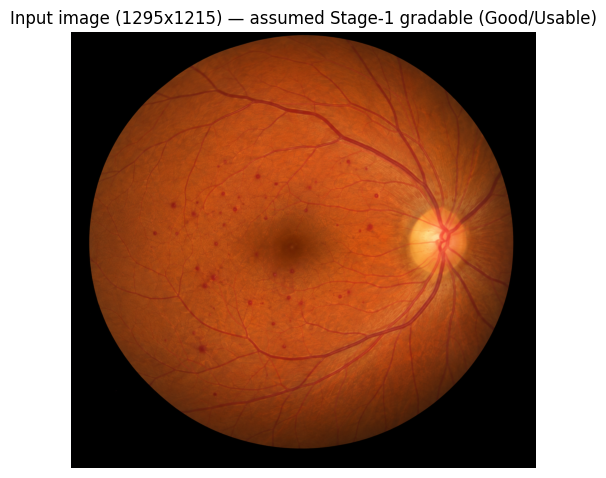

In [13]:
from fundus_data_toolkit.functional import open_image

raw_image = open_image(IMAGE_PATH)          # RGB uint8 numpy array, HxWx3
H, W = raw_image.shape[:2]
print(f"Loaded image: {raw_image.shape}, dtype={raw_image.dtype}")

plt.figure(figsize=(6, 6))
plt.imshow(raw_image)
plt.title(f"Input image ({W}x{H}) — assumed Stage-1 gradable (Good/Usable)")
plt.axis("off")
plt.show()


## 4. Stage 2a — Lesion segmentation
(`fundus-lesions-toolkit`: Microaneurysms, Exudates, Hemorrhages, Cotton-Wool-Spots)

Classes: ['BG', 'CTW', 'EX', 'HE', 'MA']
[ClementP/fundus-lesions-segmentation-unet_seresnext50_32x4d] config.json: {'arch': 'unet', 'encoder': 'seresnext50_32x4d', 'in_chans': 3, 'log_dice': False, 'lr': 0.003, 'n_classes': 5, 'optimizer': 'adamw', 'pretrained': True, 'smooth_dice': 0.4, 'test_dataset_id': ['IDRID', 'FGADR', 'MESSIDOR', 'DDR', 'RETLES']}


model.safetensors: reconstructing file:   0%|          |  0.00B /  111MB            

model.safetensors: downloading bytes:           |  0.00B            

[ClementP/fundus-lesions-segmentation-unet_seresnext50_32x4d] loaded with encoder_name='tu-seresnext50_32x4d' — missing=0, unexpected=0
Lesion mask source: Hugging Face Hub direct load (ClementP/fundus-lesions-segmentation-unet_seresnext50_32x4d), tu-encoder, autocropped input
Raw lesion prediction shape (C,H,W): (5, 1215, 1295)


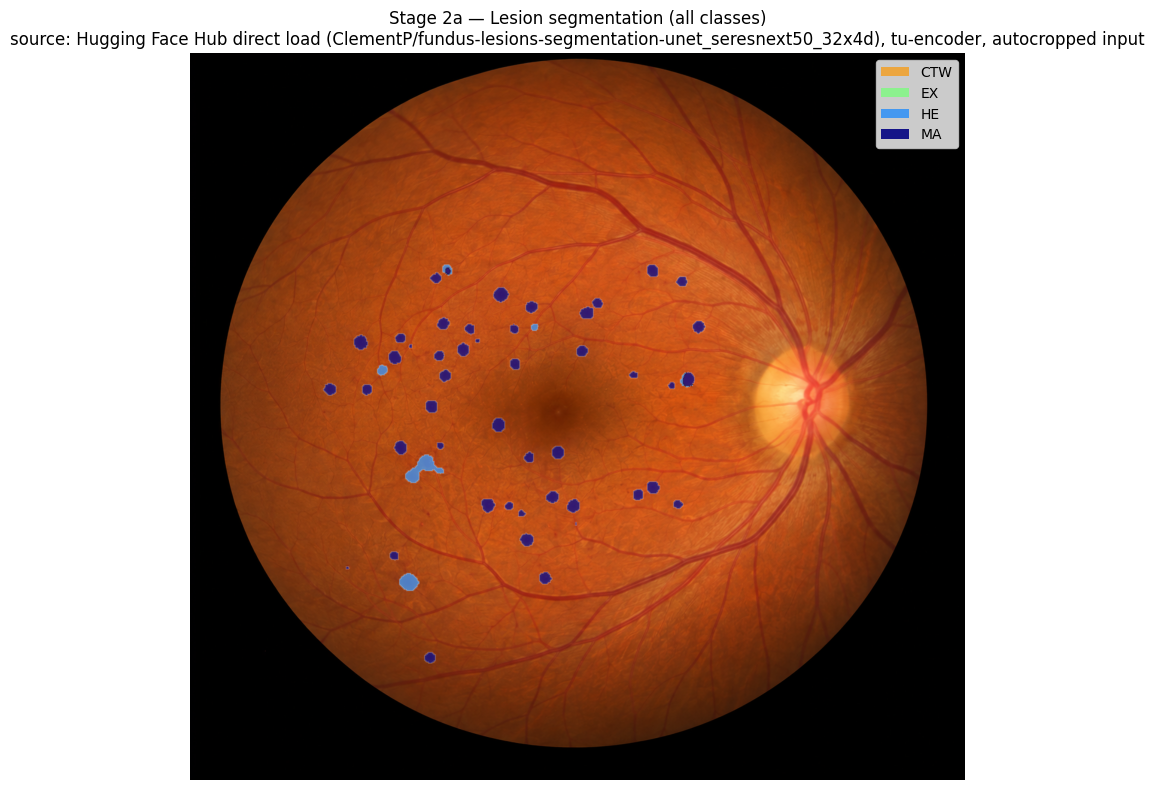

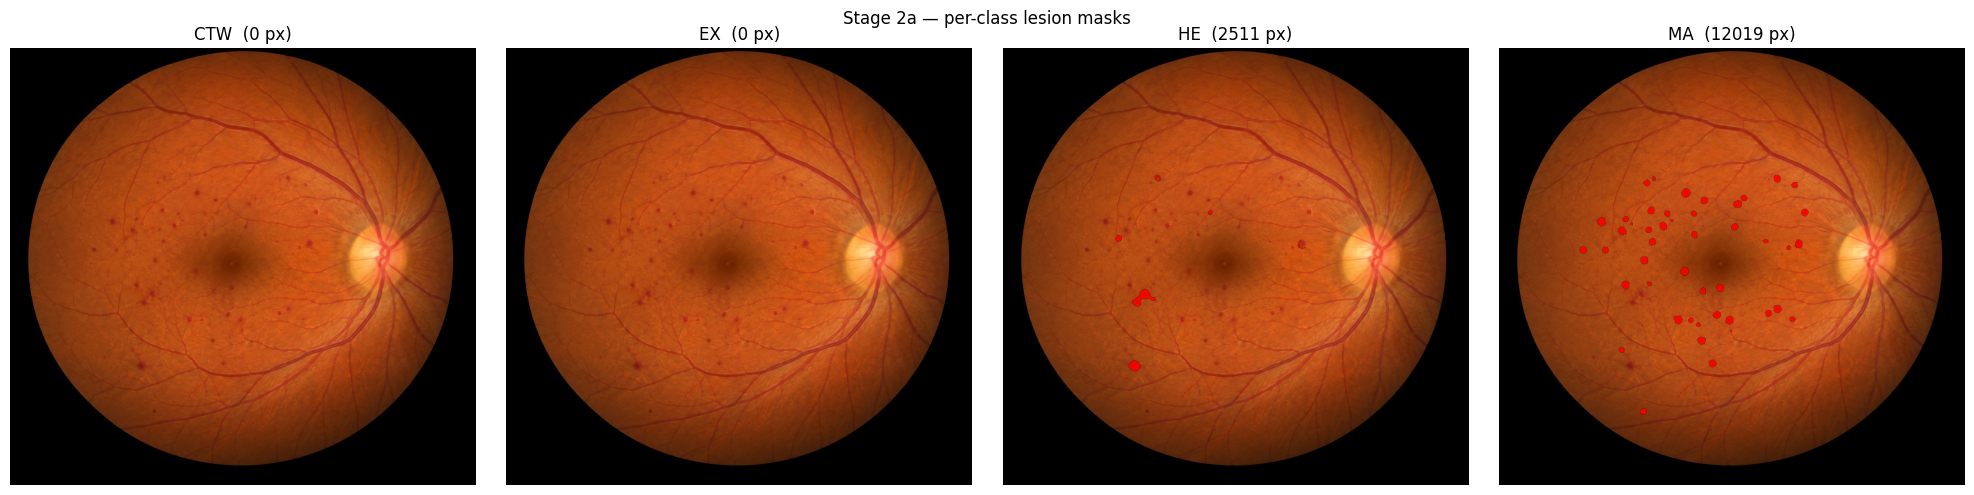

  CTW: 0 px  |  connected components: 0
  EX: 0 px  |  connected components: 0
  HE: 2511 px  |  connected components: 8
  MA: 12019 px  |  connected components: 47


In [23]:
import json, subprocess, sys, importlib

for pkg in ("huggingface_hub", "safetensors"):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

from huggingface_hub import hf_hub_download
from safetensors.torch import load_file as load_safetensors
import segmentation_models_pytorch as smp

from fundus_lesions_toolkit.constants import DEFAULT_COLORS, LESIONS
from fundus_lesions_toolkit.utils.visualization import plot_image_and_mask

print("Classes:", LESIONS)  # ['BG', 'CTW', 'EX', 'HE', 'MA']

LESION_HF_REPO = "ClementP/fundus-lesions-segmentation-unet_seresnext50_32x4d"

def autocrop_fundus_simple(img_rgb, threshold=10):
    gray = img_rgb.astype(np.int32).sum(axis=2)
    mask = gray > threshold
    if not mask.any():
        H, W = img_rgb.shape[:2]
        return img_rgb, (0, H, 0, W)
    ys, xs = np.nonzero(mask)
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    x0, x1 = int(xs.min()), int(xs.max()) + 1
    return img_rgb[y0:y1, x0:x1], (y0, y1, x0, x1)

def _strip_prefix(state_dict, prefix="model."):
    if all(k.startswith(prefix) for k in state_dict):
        return {k[len(prefix):]: v for k, v in state_dict.items()}
    return state_dict

# smp classic-encoder spelling -> timm's actual model name (they differ for the SE- family)
_TIMM_NAME_OVERRIDES = {
    "se_resnext50_32x4d": "seresnext50_32x4d",
    "se_resnext101_32x4d": "seresnext101_32x4d",
    "se_resnet50": "seresnet50",
    "se_resnet101": "seresnet101",
    "se_resnet152": "seresnet152",
}

def load_smp_model_from_hf(repo_id, device, arch="unet", encoder_name="se_resnext50_32x4d",
                            in_channels=3, num_classes=5):
    '''
    These checkpoints: (1) were saved from a wrapper class, so every key has a
    "model." prefix that must be stripped, and (2) use a *timm* encoder (flat
    conv1/bn1 stem, "se.fc1/fc2" naming) rather than smp's classic
    pretrainedmodels-style encoder. timm's model-name spelling for the
    SE-ResNeXt/ResNet family also differs from smp's classic spelling
    (no underscore after "se"), hence the override table above.
    '''
    config_path = hf_hub_download(repo_id, filename="config.json")
    weights_path = hf_hub_download(repo_id, filename="model.safetensors")
    with open(config_path) as f:
        print(f"[{repo_id}] config.json:", json.load(f))

    raw_state_dict = load_safetensors(weights_path)
    state_dict = _strip_prefix(raw_state_dict, "model.")

    timm_base_name = _TIMM_NAME_OVERRIDES.get(encoder_name, encoder_name)
    tu_encoder_name = f"tu-{timm_base_name}"

    model = smp.create_model(arch=arch, encoder_name=tu_encoder_name,
                              in_channels=in_channels, classes=num_classes)

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print(f"[{repo_id}] loaded with encoder_name={tu_encoder_name!r} — "
          f"missing={len(missing)}, unexpected={len(unexpected)}")
    if missing or unexpected:
        print(f"  Missing (first 10): {missing[:10]}")
        print(f"  Unexpected (first 10): {unexpected[:10]}")
        if len(missing) > 5 or len(unexpected) > 5:
            raise RuntimeError(
                f"Weights for {repo_id} did not line up with encoder_name={tu_encoder_name!r} "
                f"({len(missing)} missing / {len(unexpected)} unexpected) — not safe to run inference."
            )
    return model.to(device).eval()

def segment_lesions_via_hf(image_rgb, device, size=512, num_classes=5):
    model = load_smp_model_from_hf(LESION_HF_REPO, device, num_classes=num_classes)
    preprocess_fn = smp.encoders.get_preprocessing_fn("se_resnext50_32x4d", pretrained="imagenet")

    H0, W0 = image_rgb.shape[:2]
    cropped, (y0, y1, x0, x1) = autocrop_fundus_simple(image_rgb)
    Hc, Wc = cropped.shape[:2]

    img_r = sk_resize(cropped, (size, size), order=1, preserve_range=True, anti_aliasing=True)
    img_n = preprocess_fn(img_r.astype(np.float32))
    x = torch.from_numpy(img_n.transpose(2, 0, 1)).unsqueeze(0).float().to(device)

    with torch.no_grad():
        probs_crop_model_res = torch.softmax(model(x), dim=1)[0].cpu().numpy()

    probs_crop = np.stack([
        sk_resize(probs_crop_model_res[c], (Hc, Wc), order=1, preserve_range=True, anti_aliasing=True)
        for c in range(num_classes)
    ])
    probs_full = np.zeros((num_classes, H0, W0), dtype=np.float32)
    probs_full[0] = 1.0
    probs_full[:, y0:y1, x0:x1] = probs_crop
    return torch.from_numpy(probs_full)

lesion_pred = segment_lesions_via_hf(raw_image, DEVICE)
lesion_source = f"Hugging Face Hub direct load ({LESION_HF_REPO}), tu-encoder, autocropped input"

lesion_pred = lesion_pred.detach().cpu().numpy() if torch.is_tensor(lesion_pred) else np.asarray(lesion_pred)
print(f"Lesion mask source: {lesion_source}")
print("Raw lesion prediction shape (C,H,W):", lesion_pred.shape)

lesion_argmax = lesion_pred.argmax(axis=0)
lesion_masks = np.stack([(lesion_argmax == i) for i in range(1, len(LESIONS))])

plot_image_and_mask(
    raw_image, torch.as_tensor(lesion_pred), alpha=0.8,
    title=f"Stage 2a — Lesion segmentation (all classes)\nsource: {lesion_source}",
    colors=DEFAULT_COLORS, labels=LESIONS
)
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, name in enumerate(LESIONS[1:]):
    axes[i].imshow(raw_image)
    axes[i].imshow(np.ma.masked_where(~lesion_masks[i], lesion_masks[i]), cmap="autumn", alpha=0.9)
    axes[i].set_title(f"{name}  ({lesion_masks[i].sum()} px)")
    axes[i].axis("off")
plt.suptitle("Stage 2a — per-class lesion masks")
plt.tight_layout()
plt.show()

for i, name in enumerate(LESIONS[1:]):
    print(f"  {name}: {int(lesion_masks[i].sum())} px  |  connected components: "
          f"{label(lesion_masks[i]).max()}")

## 5. Stage 2b — Optic Disc / Macula localization
(`fundus-odmac-toolkit`)

[ClementP/fundus-odmac-segmentation-unet-seresnet50] config.json: {'arch': 'unet', 'classes': 3, 'encoder': 'seresnet50', 'in_channels': 3}


model.safetensors: reconstructing file:   0%|          |  0.00B /  113MB            

model.safetensors: downloading bytes:           |  0.00B            

[ClementP/fundus-odmac-segmentation-unet-seresnet50] loaded with encoder_name='tu-seresnet50' — missing=0, unexpected=0


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Raw OD/macula prediction shape (3,H,W) [BG, OD, Macula]: (3, 1215, 1295)
OD pixels: 21619   Macula pixels: 19209
Macula point (row, col): (611.9, 720.2)


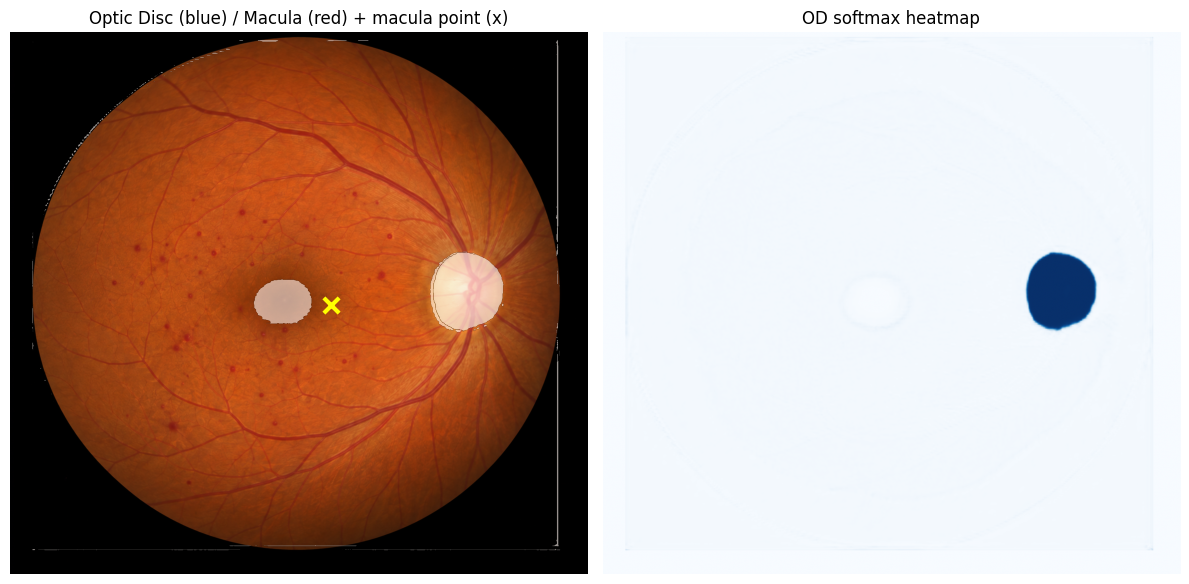

In [24]:
ODMAC_HF_REPO = "ClementP/fundus-odmac-segmentation-unet-seresnet50"

# smp.encoders.get_preprocessing_fn only recognizes smp's "classic" encoder spelling
# (e.g. "se_resnet50", with the underscore after "se") — NOT the timm/repo spelling
# ("seresnet50") that load_smp_model_from_hf's _TIMM_NAME_OVERRIDES table maps for the
# model itself. This is a separate mapping, used only for looking up the imagenet
# preprocessing stats (mean/std/input range), not for building the model.
_SMP_CLASSIC_PREPROCESS_OVERRIDES = {
    "seresnext50_32x4d": "se_resnext50_32x4d",
    "seresnext101_32x4d": "se_resnext101_32x4d",
    "seresnet50": "se_resnet50",
    "seresnet101": "se_resnet101",
    "seresnet152": "se_resnet152",
}

def segment_odmac_via_hf(image_rgb, device, size=512, num_classes=3):
    # bypasses fundus_odmac_toolkit.segment() entirely — its autocrop_fundus() call
    # crashes on this OpenCV version regardless of image content
    encoder_name = "seresnet50"
    model = load_smp_model_from_hf(ODMAC_HF_REPO, device, arch="unet",
                                    encoder_name=encoder_name, num_classes=num_classes)

    smp_classic_name = _SMP_CLASSIC_PREPROCESS_OVERRIDES.get(encoder_name, encoder_name)
    preprocess_fn = smp.encoders.get_preprocessing_fn(smp_classic_name, pretrained="imagenet")

    H0, W0 = image_rgb.shape[:2]
    cropped, (y0, y1, x0, x1) = autocrop_fundus_simple(image_rgb)
    Hc, Wc = cropped.shape[:2]

    img_r = sk_resize(cropped, (size, size), order=1, preserve_range=True, anti_aliasing=True)
    img_n = preprocess_fn(img_r.astype(np.float32))
    x = torch.from_numpy(img_n.transpose(2, 0, 1)).unsqueeze(0).float().to(device)

    with torch.no_grad():
        probs_crop_model_res = torch.softmax(model(x), dim=1)[0].cpu().numpy()  # (3, size, size)

    probs_crop = np.stack([
        sk_resize(probs_crop_model_res[c], (Hc, Wc), order=1, preserve_range=True, anti_aliasing=True)
        for c in range(num_classes)
    ])
    probs_full = np.zeros((num_classes, H0, W0), dtype=np.float32)
    probs_full[0] = 1.0
    probs_full[:, y0:y1, x0:x1] = probs_crop
    return torch.from_numpy(probs_full)

odmac_pred = segment_odmac_via_hf(raw_image, DEVICE)
odmac_pred = odmac_pred.detach().cpu().numpy() if torch.is_tensor(odmac_pred) else np.asarray(odmac_pred)
print("Raw OD/macula prediction shape (3,H,W) [BG, OD, Macula]:", odmac_pred.shape)

odmac_argmax = odmac_pred.argmax(axis=0)
od_mask = (odmac_argmax == 1)
macula_mask = (odmac_argmax == 2)

macula_prob = odmac_pred[2]
if macula_mask.sum() > 0:
    ys, xs = np.nonzero(macula_mask)
    weights = macula_prob[ys, xs]
    macula_point = (float(np.average(ys, weights=weights)), float(np.average(xs, weights=weights)))
else:
    macula_point = np.unravel_index(np.argmax(macula_prob), macula_prob.shape)
    macula_point = (float(macula_point[0]), float(macula_point[1]))

print(f"OD pixels: {int(od_mask.sum())}   Macula pixels: {int(macula_mask.sum())}")
print(f"Macula point (row, col): ({macula_point[0]:.1f}, {macula_point[1]:.1f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(raw_image)
axes[0].imshow(np.ma.masked_where(~od_mask, od_mask), cmap="Blues", alpha=0.6)
axes[0].imshow(np.ma.masked_where(~macula_mask, macula_mask), cmap="Reds", alpha=0.6)
axes[0].scatter([macula_point[1]], [macula_point[0]], marker="x", c="yellow", s=120, linewidths=3)
axes[0].set_title("Optic Disc (blue) / Macula (red) + macula point (x)")
axes[0].axis("off")
axes[1].imshow(odmac_pred[1], cmap="Blues")
axes[1].set_title("OD softmax heatmap")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 6. Stage 2c — Vessel segmentation

First attempts the pretrained `DIAGNijmegen/drive-vessels-unet` MONAI U-Net. If the weight file
(Git-LFS hosted) or any dependency is unavailable, this **automatically falls back** to a classical,
dependency-free CLAHE + multi-scale Frangi vesselness pipeline — so this cell always produces a
usable vessel mask regardless of network conditions.

Attempting pretrained DIAGNijmegen vessel U-Net...
  [pretrained vessel model] attempt 1/2 failed: Git-LFS weight file did not resolve to real binary content
  [pretrained vessel model] attempt 2/2 failed: Git-LFS weight file did not resolve to real binary content
Pretrained vessel model unavailable (RuntimeError: Git-LFS weight file did not resolve to real binary content).
Falling back to classical CLAHE + Frangi vesselness pipeline (guaranteed to work offline).

Vessel mask source: classical CLAHE + multi-scale Frangi vesselness (fallback)
Vessel pixels: 48650  (3.09% of full frame)


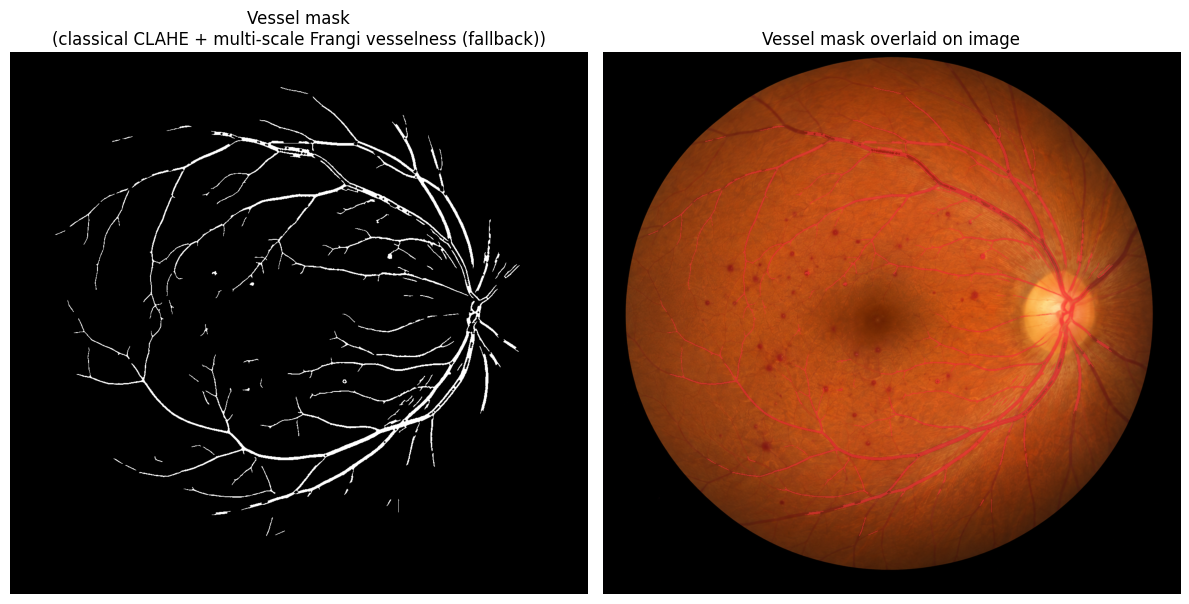

In [25]:
def try_pretrained_vessel_model(image_rgb, device):
    '''Best-effort pretrained U-Net (DIAGNijmegen/drive-vessels-unet). Raises on any failure.'''
    import subprocess, sys, importlib
    for pkg in ("monai",):
        try:
            importlib.import_module(pkg)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
    import monai
    from skimage.transform import resize as _resize

    repo_dir = "drive_vessels_unet_repo"
    if not os.path.isdir(repo_dir):
        subprocess.run(["git", "clone", "--depth", "1",
                         "https://github.com/DIAGNijmegen/drive-vessels-unet.git", repo_dir],
                        check=True, capture_output=True)
        subprocess.run(["git", "lfs", "pull"], cwd=repo_dir, check=True, capture_output=True)

    weight_path = os.path.join(repo_dir, "best_metric_model_segmentation2d_dict.pth")
    if os.path.getsize(weight_path) < 10_000:  # still an LFS pointer, not the real binary
        raise RuntimeError("Git-LFS weight file did not resolve to real binary content")

    model = monai.networks.nets.UNet(
        spatial_dims=2, in_channels=3, out_channels=1,
        channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2), num_res_units=2,
    ).to(device)
    model.load_state_dict(torch.load(weight_path, map_location=device))
    model.eval()

    img_512 = _resize(image_rgb, (512, 512), order=3, preserve_range=True, anti_aliasing=True)
    img_512 = (img_512.astype(np.float32) / 255.0).transpose(2, 0, 1)
    x = torch.from_numpy(img_512).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.sigmoid(model(x))[0, 0].cpu().numpy()
    vessel_mask_512 = pred > 0.5
    vessel_mask = _resize(vessel_mask_512.astype(float), image_rgb.shape[:2],
                           order=0, preserve_range=True) > 0.5
    return vessel_mask


def classical_vessel_segmentation(image_rgb):
    '''Dependency-free CLAHE + multi-scale Frangi vesselness. Always succeeds.'''
    gray_sum = image_rgb.sum(axis=2).astype(np.float32)
    fov = gray_sum > (0.06 * 255 * 3)
    fov = morphology.erosion(fov, morphology.disk(max(3, int(0.01 * min(image_rgb.shape[:2])))))
    fov = morphology.remove_small_objects(fov, min_size=int(0.001 * fov.size))

    green = image_rgb[:, :, 1].astype(np.float32) / 255.0
    green_masked = green * fov
    green_eq = exposure.equalize_adapthist(green_masked, clip_limit=0.01)
    inv = 1.0 - green_eq

    vesselness = filters.frangi(inv, sigmas=np.arange(1, 5, 0.5), black_ridges=False)
    vesselness[~fov] = 0

    vals = vesselness[fov]
    thr = filters.threshold_otsu(vals) if vals.max() > 0 else 0.5
    mask = (vesselness > thr * 0.6) & fov
    mask = morphology.remove_small_objects(mask, min_size=max(20, int(0.00002 * fov.size)))
    mask = morphology.binary_closing(mask, morphology.disk(2))
    return mask


try:
    print("Attempting pretrained DIAGNijmegen vessel U-Net...")
    vessel_mask = retry(try_pretrained_vessel_model, raw_image, DEVICE,
                         attempts=2, delay=2, label="pretrained vessel model")
    vessel_source = "pretrained U-Net (DIAGNijmegen/drive-vessels-unet)"
except Exception as e:
    print(f"Pretrained vessel model unavailable ({type(e).__name__}: {e}).")
    print("Falling back to classical CLAHE + Frangi vesselness pipeline (guaranteed to work offline).")
    vessel_mask = classical_vessel_segmentation(raw_image)
    vessel_source = "classical CLAHE + multi-scale Frangi vesselness (fallback)"

print(f"\nVessel mask source: {vessel_source}")
print(f"Vessel pixels: {int(vessel_mask.sum())}  ({100 * vessel_mask.mean():.2f}% of full frame)")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(vessel_mask, cmap="gray")
axes[0].set_title(f"Vessel mask\n({vessel_source})")
axes[0].axis("off")

overlay = raw_image.copy()
vessel_color = np.array([255, 60, 60])
alpha_v = 0.55
overlay_f = overlay.astype(float)
overlay_f[vessel_mask] = (1 - alpha_v) * overlay_f[vessel_mask] + alpha_v * vessel_color
axes[1].imshow(overlay_f.astype(np.uint8))
axes[1].set_title("Vessel mask overlaid on image")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## 7. Canonical registration

All three branches were computed at (possibly different) native resolutions. Per the architecture,
everything is now resized/registered to one shared **512×512 canonical frame** and packed into the
output bundle that Stage 3 expects:

```
{lesion_masks[4], od_mask, macula_point, vessel_mask}
```

In [26]:
img_c = to_canonical(raw_image, is_mask=False)

lesion_masks_c = np.stack([to_canonical(lesion_masks[i], is_mask=True) for i in range(4)])
od_mask_c = to_canonical(od_mask, is_mask=True)
vessel_mask_c = to_canonical(vessel_mask, is_mask=True)

scale_y, scale_x = CANON / H, CANON / W
macula_point_c = (macula_point[0] * scale_y, macula_point[1] * scale_x)

output_bundle = {
    "canonical_image": img_c,                 # (512,512,3) uint8
    "lesion_masks": lesion_masks_c,            # (4,512,512) bool -> order: CTW, EX, HE, MA
    "lesion_class_names": LESIONS[1:],
    "od_mask": od_mask_c,                      # (512,512) bool
    "macula_point": macula_point_c,            # (row, col) in canonical frame
    "vessel_mask": vessel_mask_c,              # (512,512) bool
    "vessel_source": vessel_source,
    "canonical_resolution": CANON,
}

print("Canonical output bundle:")
for k, v in output_bundle.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: {v}")


Canonical output bundle:
  canonical_image: shape=(512, 512, 3), dtype=uint8
  lesion_masks: shape=(4, 512, 512), dtype=bool
  lesion_class_names: ['CTW', 'EX', 'HE', 'MA']
  od_mask: shape=(512, 512), dtype=bool
  macula_point: (257.850448478056, 284.75616251657783)
  vessel_mask: shape=(512, 512), dtype=bool
  vessel_source: classical CLAHE + multi-scale Frangi vesselness (fallback)
  canonical_resolution: 512


## 8. Fused evidence overlay (Stage 4 preview)

Single composited image, as specified in the architecture's Stage 4:
- vessels: thin, low opacity
- OD / macula: outlined
- lesions: color-coded by class, **highest opacity** since they drive the ICDR grade

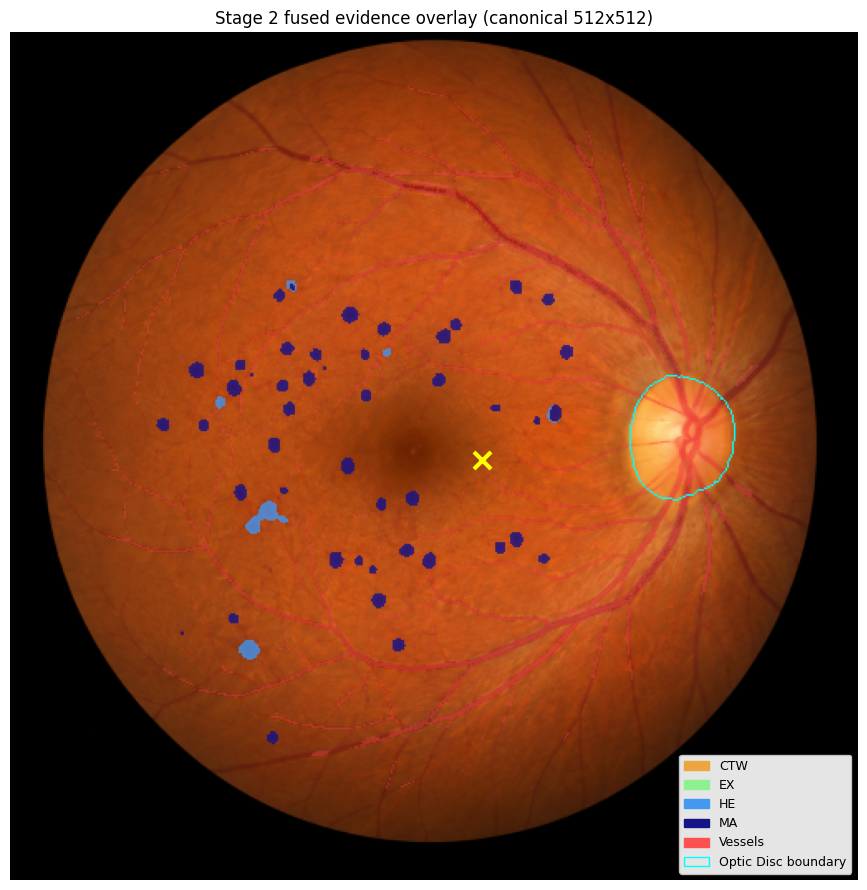

In [27]:
fused = img_c.astype(float).copy()

# 1) Vessels — thin, low opacity
vessel_color = np.array([255, 80, 80])
alpha_vessel = 0.35
fused[vessel_mask_c] = (1 - alpha_vessel) * fused[vessel_mask_c] + alpha_vessel * vessel_color

# 2) OD / macula — outlined only
od_boundary = find_boundaries(od_mask_c, mode="outer") if od_mask_c.any() else np.zeros_like(od_mask_c)
fused[od_boundary] = [0, 255, 255]

# 3) Lesions — color-coded, highest opacity, drawn last (on top)
lesion_colors = {
    "CTW": (236, 166, 63),
    "EX":  (140, 241, 142),
    "HE":  (68, 152, 240),
    "MA":  (20, 20, 136),
}
alpha_lesion = 0.8
for i, name in enumerate(LESIONS[1:]):
    m = lesion_masks_c[i]
    if not m.any():
        continue
    color = np.array(lesion_colors[name])
    fused[m] = (1 - alpha_lesion) * fused[m] + alpha_lesion * color

fused = np.clip(fused, 0, 255).astype(np.uint8)

macula_row, macula_col = macula_point_c

plt.figure(figsize=(9, 9))
plt.imshow(fused)
plt.scatter([macula_col], [macula_row], marker="x", c="yellow", s=150, linewidths=3, label="Macula")
legend_patches = [mpatches.Patch(color=np.array(c) / 255, label=n) for n, c in lesion_colors.items()]
legend_patches.append(mpatches.Patch(color=np.array(vessel_color) / 255, label="Vessels"))
legend_patches.append(mpatches.Patch(edgecolor="cyan", facecolor="none", label="Optic Disc boundary"))
plt.legend(handles=legend_patches, loc="lower right", fontsize=9, framealpha=0.9)
plt.title("Stage 2 fused evidence overlay (canonical 512x512)")
plt.axis("off")
plt.tight_layout()
plt.show()


## 9. Structured features for Stage 3 fusion

The architecture's Stage 3 concatenates the CNN embedding with a structured feature vector derived
from these Stage 2 masks: lesion pixel counts / connected-component counts per class, nearest-lesion-
to-macula distance, and vessel density per quadrant. Computed and printed here so you can sanity
check them before wiring into the grading model.

In [28]:
rows = []
macula_xy = np.array([macula_row, macula_col])

for i, name in enumerate(LESIONS[1:]):
    m = lesion_masks_c[i]
    px_count = int(m.sum())
    lbl = label(m)
    n_components = int(lbl.max())
    if n_components > 0:
        centroids = np.array([p.centroid for p in regionprops(lbl)])
        dist_to_macula = float(np.min(np.sqrt(((centroids - macula_xy) ** 2).sum(axis=1))))
    else:
        dist_to_macula = float("nan")
    rows.append({
        "lesion_class": name,
        "pixel_count": px_count,
        "connected_components": n_components,
        "nearest_to_macula_px": round(dist_to_macula, 1) if n_components else None,
    })

lesion_features_df = pd.DataFrame(rows)
print("Lesion features (canonical 512x512 frame):")
display(lesion_features_df)

cy, cx = CANON // 2, CANON // 2
vessel_density = {
    "TL": float(vessel_mask_c[:cy, :cx].mean()),
    "TR": float(vessel_mask_c[:cy, cx:].mean()),
    "BL": float(vessel_mask_c[cy:, :cx].mean()),
    "BR": float(vessel_mask_c[cy:, cx:].mean()),
}
vessel_density_df = pd.DataFrame([vessel_density])
print("\nVessel density per quadrant (fraction of quadrant area):")
display(vessel_density_df)

od_area_px = int(od_mask_c.sum())
print(f"\nOptic disc area: {od_area_px} px  |  Macula point (canonical): "
      f"({macula_row:.1f}, {macula_col:.1f})")


Lesion features (canonical 512x512 frame):


,lesion_class,pixel_count,connected_components,nearest_to_macula_px
0,CTW,0,0,NaN
1,EX,0,0,NaN
2,HE,426,7,49.0
3,MA,2013,46,32.3



Vessel density per quadrant (fraction of quadrant area):


,TL,TR,BL,BR
0,0.022217,0.042542,0.019287,0.039444



Optic disc area: 3600 px  |  Macula point (canonical): (257.9, 284.8)


## 10. Save the Stage 2 output bundle

Persists everything Stage 3/4 need for this image.

In [29]:
os.makedirs("stage2_outputs", exist_ok=True)
base_name = os.path.splitext(os.path.basename(IMAGE_PATH))[0]
out_path = os.path.join("stage2_outputs", f"{base_name}_stage2_bundle.pkl")

save_bundle = dict(output_bundle)
save_bundle["lesion_features"] = lesion_features_df
save_bundle["vessel_density"] = vessel_density_df

with open(out_path, "wb") as f:
    pickle.dump(save_bundle, f)

print(f"Saved Stage 2 output bundle to: {out_path}")
print("\nSTAGE 2 COMPLETE — all three segmentation branches ran successfully and were registered "
      "to the shared 512x512 canonical frame. This bundle is ready to feed the Stage 3 "
      "image+mask-fusion grading model.")


Saved Stage 2 output bundle to: stage2_outputs/MA LESION (1)_stage2_bundle.pkl

STAGE 2 COMPLETE — all three segmentation branches ran successfully and were registered to the shared 512x512 canonical frame. This bundle is ready to feed the Stage 3 image+mask-fusion grading model.
